In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        b[(ch1, ch2)] = b.get((ch1, ch2), 0) + 1

b


{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [3]:
sorted(b.items(), key = lambda x: -x[1])

[(('a', '<E>'), 3),
 (('<S>', 'e'), 1),
 (('e', 'm'), 1),
 (('m', 'm'), 1),
 (('m', 'a'), 1),
 (('<S>', 'o'), 1),
 (('o', 'l'), 1),
 (('l', 'i'), 1),
 (('i', 'v'), 1),
 (('v', 'i'), 1),
 (('i', 'a'), 1),
 (('<S>', 'a'), 1),
 (('a', 'v'), 1),
 (('v', 'a'), 1)]

In [4]:
import torch

In [5]:
N = torch.zeros((27, 27), dtype=torch.int32)


In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [7]:

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        N[ix1, ix2] += 1



(-0.5, 26.5, 26.5, -0.5)

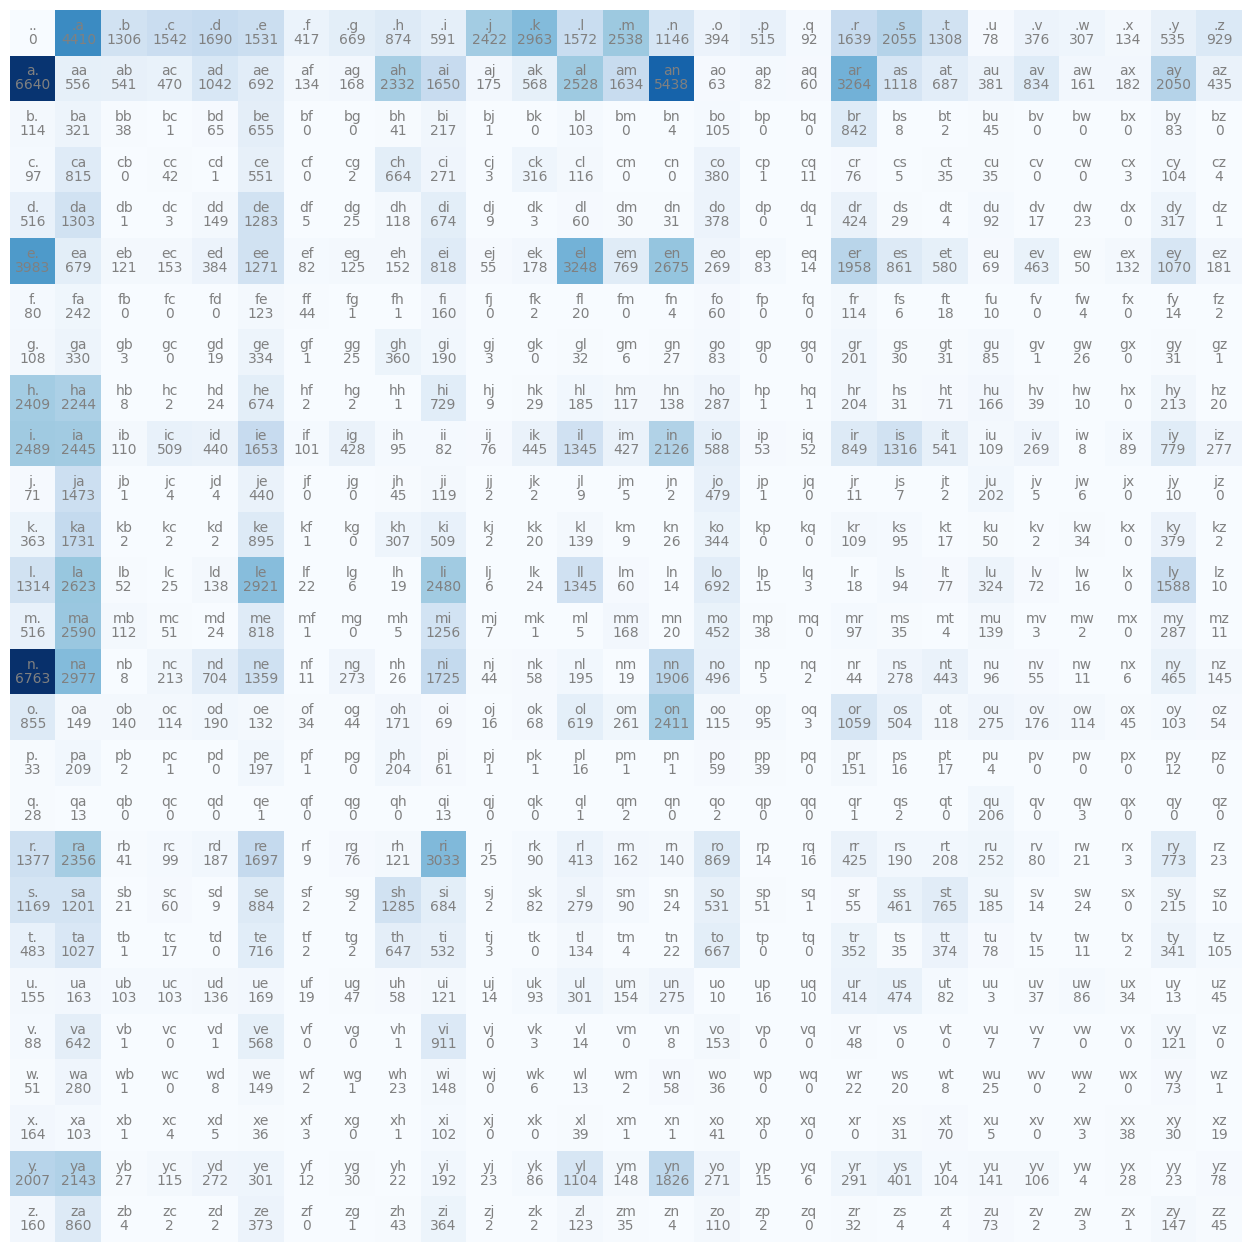

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="Blues")

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")

plt.axis("off")

In [9]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [10]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [11]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples= 1, replacement=True, generator=g).item()
ix

10

In [12]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator = g)
p = p / p.sum()
p 

tensor([0.6064, 0.3033, 0.0903])

In [13]:
torch.multinomial(p, num_samples= 1, replacement=True, generator=g).item()

0

In [14]:
P = N.float()
P /= P.sum(1, keepdim = True) # keepdim 会保留一行张量，使其可以尽心广播操作

In [15]:
print(P[0].sum())

tensor(1.)


In [16]:
g = torch.Generator().manual_seed(2147483647)


for _ in range(10):
    
    out = []
    ix = 0
    while True:
        p = P[ix]

        # p = torch.ones(27) / 27.0

        ix = torch.multinomial(p, num_samples= 1, replacement=True, generator=g).item()
        out.append(itos[ix])

        if ix == 0:
            break

    print(''.join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.


In [17]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [18]:
log_likelihood = 0.0
n = 0

for w in words[:]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]

        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}:{prob:.4f} {logprob:.4f}')

print(f'{log_likelihood:.4f}')
nll = -log_likelihood
print(f'nll:{nll}')
print(f'nll:{nll/n}')

.e:0.0478 -3.0408
em:0.0377 -3.2793
mm:0.0253 -3.6772
ma:0.3899 -0.9418
a.:0.1960 -1.6299
.o:0.0123 -4.3982
ol:0.0780 -2.5508
li:0.1777 -1.7278
iv:0.0152 -4.1867
vi:0.3541 -1.0383
ia:0.1381 -1.9796
a.:0.1960 -1.6299
.a:0.1377 -1.9829
av:0.0246 -3.7045
va:0.2495 -1.3882
a.:0.1960 -1.6299
.i:0.0184 -3.9927
is:0.0743 -2.5990
sa:0.1482 -1.9094
ab:0.0160 -4.1373
be:0.2476 -1.3958
el:0.1590 -1.8386
ll:0.0964 -2.3397
la:0.1879 -1.6717
a.:0.1960 -1.6299
.s:0.0642 -2.7465
so:0.0655 -2.7256
op:0.0120 -4.4250
ph:0.1988 -1.6153
hi:0.0957 -2.3463
ia:0.1381 -1.9796
a.:0.1960 -1.6299
.c:0.0481 -3.0337
ch:0.1880 -1.6713
ha:0.2946 -1.2220
ar:0.0963 -2.3400
rl:0.0325 -3.4259
lo:0.0496 -3.0042
ot:0.0149 -4.2082
tt:0.0671 -2.7009
te:0.1285 -2.0515
e.:0.1950 -1.6346
.m:0.0792 -2.5354
mi:0.1891 -1.6655
ia:0.1381 -1.9796
a.:0.1960 -1.6299
.a:0.1377 -1.9829
am:0.0482 -3.0319
me:0.1232 -2.0943
el:0.1590 -1.8386
li:0.1777 -1.7278
ia:0.1381 -1.9796
a.:0.1960 -1.6299
.h:0.0273 -3.6014
ha:0.2946 -1.2220
ar:0.0963 

In [19]:
# create train set of bigrams (x, y)
xs, ys = [], []


for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
    

In [20]:
xs

tensor([ 0,  5, 13, 13,  1])

In [21]:
ys

tensor([ 5, 13, 13,  1,  0])

In [22]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

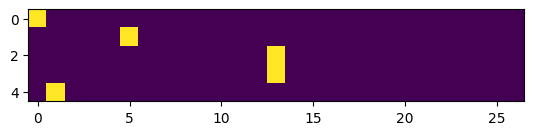

In [23]:
plt.imshow(xenc)

In [34]:
xenc.dtype
xenc = F.one_hot(xs, num_classes = 27).float()
W = torch.randn((27, 27))
logits = xenc @ W


In [30]:
# 5, 27   27, 27    5, 27

In [35]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad = True)

In [36]:
# forward pass
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [37]:
nlls = torch.zeros(5)
for i in range(5): # Bigrams for "Emma"
    # i-th bigram:
    x = ys[i].item() # input character index
    y = ys[i].item() # label character index
    print('------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

------
bigram example 1: ee (indexes 5,5)
input to the neural net 5
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
------
bigram example 2: mm (indexes 13,13)
input to the neural net 13
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
       grad_fn=<SelectBackward0>)
label (actual next character): 13
prob

In [38]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [39]:
xenc = F.one_hot(xs, num_classes=27).float() # the input to the network
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for the next character
loss = -probs[torch.arange(5), ys].log().mean()

In [40]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()

In [41]:
W.data += -0.1 * W.grad # the update to the tensor

In [42]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement() # returns the total nr of elements stored
print('nr of elements:', num)

# initialize the network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

nr of elements: 228146


In [43]:
(W**2).mean() # Regularization; pushes the logits to be 0

tensor(0.9665, grad_fn=<MeanBackward0>)

In [44]:
# gradient descent
for k in range(100):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # input to the network
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts
    probs = counts / counts.sum(1, keepdims=True) # softmax

    loss = -probs[torch.arange(num), ys].log().mean() + 0.0001*(W**2).mean()

    print(f'The loss now is: {loss.item()}')


    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()


    # update
    W.data += -50 * W.grad

The loss now is: 3.7590503692626953
The loss now is: 3.3711776733398438
The loss now is: 3.154114246368408
The loss now is: 3.020442485809326
The loss now is: 2.92777943611145
The loss now is: 2.860471487045288
The loss now is: 2.8097991943359375
The loss now is: 2.7701737880706787
The loss now is: 2.7381463050842285
The loss now is: 2.711571455001831
The loss now is: 2.689079523086548
The loss now is: 2.669766902923584
The loss now is: 2.653010845184326
The loss now is: 2.638359546661377
The loss now is: 2.6254730224609375
The loss now is: 2.61407732963562
The loss now is: 2.603952646255493
The loss now is: 2.5949132442474365
The loss now is: 2.5868051052093506
The loss now is: 2.5794992446899414
The loss now is: 2.5728862285614014
The loss now is: 2.566875696182251
The loss now is: 2.5613889694213867
The loss now is: 2.5563621520996094
The loss now is: 2.551738977432251
The loss now is: 2.5474724769592285
The loss now is: 2.5435242652893066
The loss now is: 2.5398590564727783
The los

In [51]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

    out = []
    ix = 0

    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W # predict log-counts
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True).item()
        out.append(itos[ix])

        if ix == 0:
            break

    print(''.join(out))

dyosann.
tairayarayaan.
neran.
an.
zuo.
